<a href="https://colab.research.google.com/github/kraytenbb/ml/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F%20%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%20%E2%84%9613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

In [ ]:
!pip -q install osmnx h3 geopandas shapely leafmap

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import h3
import leafmap

from shapely.geometry import Point, Polygon
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

city_name = "Казань, Россия"

city = ox.geocode_to_gdf(city_name).to_crs(4326)
city_polygon = city.geometry.iloc[0]

tags_pollution = {
    "landuse": ["industrial", "landfill"],
    "man_made": ["works"],
    "power": ["plant"],
    "amenity": ["recycling", "waste_transfer_station"]
}

tags_green = {
    "leisure": ["park", "garden", "nature_reserve"],
    "landuse": ["forest", "grass", "recreation_ground"]
}

tags_water = {
    "natural": ["water"],
    "waterway": ["river", "stream", "canal"]
}

tags_roads = {
    "highway": ["motorway", "trunk", "primary", "secondary"]
}

pollution = ox.features_from_polygon(city_polygon, tags_pollution)
green = ox.features_from_polygon(city_polygon, tags_green)
water = ox.features_from_polygon(city_polygon, tags_water)
roads = ox.features_from_polygon(city_polygon, tags_roads)

pollution = pollution.reset_index()
green = green.reset_index()
water = water.reset_index()
roads = roads.reset_index()

pollution = gpd.GeoDataFrame(pollution, geometry="geometry", crs=4326)
green = gpd.GeoDataFrame(green, geometry="geometry", crs=4326)
water = gpd.GeoDataFrame(water, geometry="geometry", crs=4326)
roads = gpd.GeoDataFrame(roads, geometry="geometry", crs=4326)

print("Территория:", city_name)
print("Источники загрязнения:", len(pollution))
print("Зеленые территории:", len(green))
print("Водные объекты:", len(water))
print("Автомагистрали:", len(roads))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.6

### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [ ]:
resolution = 8

cells = h3.geo_to_cells(city_polygon, resolution)

hexagons = []

for cell in cells:
    boundary = h3.cell_to_boundary(cell)
    polygon = Polygon([(lng, lat) for lat, lng in boundary])
    hexagons.append(polygon)

grid = gpd.GeoDataFrame(
    {"h3_cell": cells},
    geometry=hexagons,
    crs=4326
)

grid["center"] = grid.geometry.centroid
centers = gpd.GeoDataFrame(
    grid[["h3_cell"]].copy(),
    geometry=grid.geometry.centroid,
    crs=4326
)

grid_metric = grid.to_crs(3857)
centers_metric = centers.to_crs(3857)

pollution_metric = pollution.to_crs(3857)
green_metric = green.to_crs(3857)
water_metric = water.to_crs(3857)
roads_metric = roads.to_crs(3857)

grid_metric["pollution_count"] = 0
grid_metric["green_area"] = 0.0
grid_metric["water_length"] = 0.0
grid_metric["road_length"] = 0.0

for i, point in enumerate(centers_metric.geometry):

    buffer_1600 = point.buffer(1600)
    buffer_800 = point.buffer(800)

    pollution_mask = pollution_metric.geometry.intersects(buffer_1600)
    grid_metric.loc[i, "pollution_count"] = pollution_mask.sum()

    green_intersection = green_metric[
        green_metric.geometry.intersects(buffer_800)
    ]

    if len(green_intersection) > 0:
        green_area = green_intersection.geometry.intersection(buffer_800).area.sum()
    else:
        green_area = 0

    grid_metric.loc[i, "green_area"] = green_area

    water_intersection = water_metric[
        water_metric.geometry.intersects(buffer_1600)
    ]

    if len(water_intersection) > 0:
        water_length = water_intersection.geometry.intersection(buffer_1600).length.sum()
    else:
        water_length = 0

    grid_metric.loc[i, "water_length"] = water_length

    roads_intersection = roads_metric[
        roads_metric.geometry.intersects(buffer_1600)
    ]

    if len(roads_intersection) > 0:
        road_length = roads_intersection.geometry.intersection(buffer_1600).length.sum()
    else:
        road_length = 0

    grid_metric.loc[i, "road_length"] = road_length

grid_metric["green_percent"] = (
    grid_metric["green_area"] /
    np.pi / 800**2 * 100
)

grid_metric["pollution_density"] = (
    grid_metric["pollution_count"] /
    (np.pi * 1600**2 / 1_000_000)
)

grid_metric["road_density"] = (
    grid_metric["road_length"] /
    (np.pi * 1600**2 / 1_000_000)
)

feature_columns = [
    "pollution_density",
    "green_percent",
    "water_length",
    "road_density"
]

features = grid_metric[feature_columns].copy()

features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(0)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

grid_metric["ecological_index"] = (
    -scaled_features[:, 0]
    + scaled_features[:, 1]
    + scaled_features[:, 2]
    - scaled_features[:, 3]
)

grid_metric = grid_metric.reset_index(drop=True)

grid = grid_metric.to_crs(4326)

grid["center"] = grid.geometry.centroid

print("Количество H3-ячеек:", len(grid))
display(grid[feature_columns + ["ecological_index"]].head())

Количество H3-ячеек: 763


,pollution_density,green_percent,water_length,road_density,ecological_index
0,0.124340,0.000000,3581.461018,0.00000,0.670113
1,0.000000,0.000000,11118.950760,0.00000,2.026177
2,0.373019,10.079733,8587.738892,2367.51158,-1.827543
3,0.000000,0.000000,0.000000,0.00000,0.385738
4,0.000000,0.000000,4857.038914,0.00000,1.102323


### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

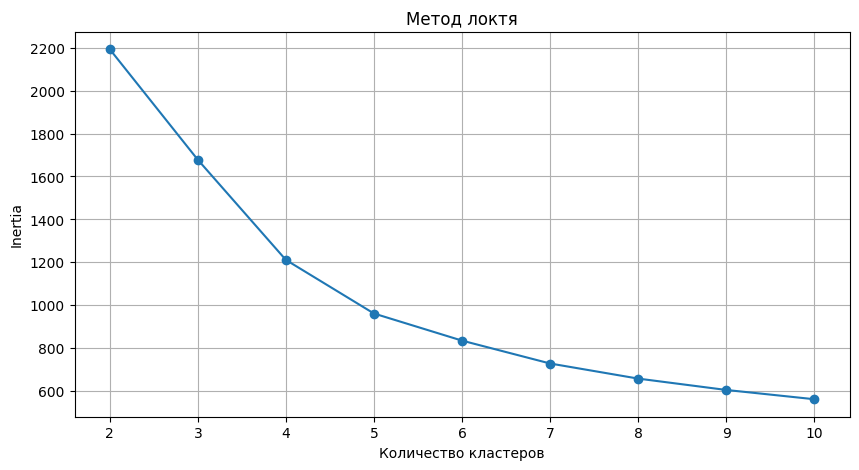

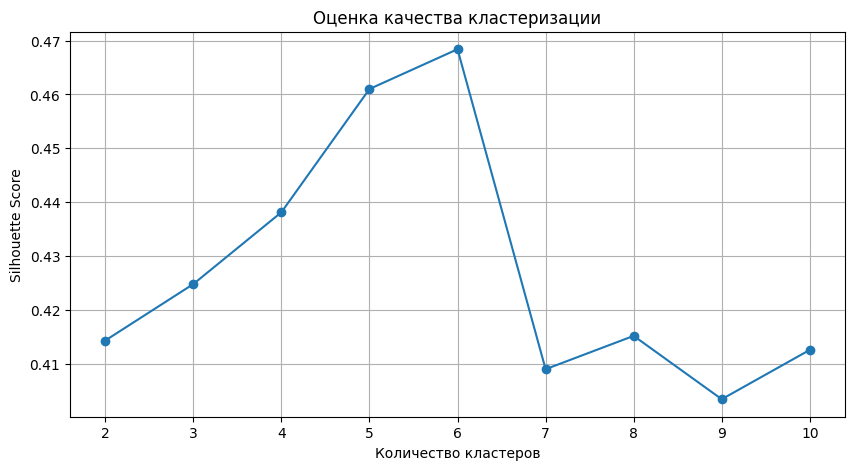

Оптимальное число кластеров: 6
Silhouette Score: 0.468393713670344


In [ ]:
X = grid[feature_columns].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []

max_clusters = min(10, len(X) - 1)

for k in range(2, max_clusters + 1):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    range(2, max_clusters + 1),
    inertia,
    marker="o"
)
ax.set_xlabel("Количество кластеров")
ax.set_ylabel("Inertia")
ax.set_title("Метод локтя")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    range(2, max_clusters + 1),
    silhouette_scores,
    marker="o"
)
ax.set_xlabel("Количество кластеров")
ax.set_ylabel("Silhouette Score")
ax.set_title("Оценка качества кластеризации")
ax.grid(True)
plt.show()

best_k = range(2, max_clusters + 1)[
    np.argmax(silhouette_scores)
]

print("Оптимальное число кластеров:", best_k)
print("Silhouette Score:", max(silhouette_scores))

### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

In [ ]:
!pip -q install hdbscan

from hdbscan import HDBSCAN

cluster_results = {}
cluster_metrics = []

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_results["K-Means"] = kmeans.fit_predict(X_scaled)

agglomerative = AgglomerativeClustering(
    n_clusters=best_k
)

cluster_results["Agglomerative"] = agglomerative.fit_predict(X_scaled)

spectral = SpectralClustering(
    n_clusters=best_k,
    random_state=42,
    affinity="nearest_neighbors"
)

cluster_results["Spectral"] = spectral.fit_predict(X_scaled)

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

cluster_results["DBSCAN"] = dbscan.fit_predict(X_scaled)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

cluster_results["HDBSCAN"] = hdbscan_model.fit_predict(X_scaled)

for name, labels in cluster_results.items():

    mask = labels != -1

    if len(set(labels[mask])) >= 2:
        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        davies = davies_bouldin_score(
            X_scaled[mask],
            labels[mask]
        )

        calinski = calinski_harabasz_score(
            X_scaled[mask],
            labels[mask]
        )
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    cluster_metrics.append([
        name,
        len(set(labels)) - (1 if -1 in labels else 0),
        (labels == -1).sum(),
        silhouette,
        davies,
        calinski
    ])

cluster_metrics_df = pd.DataFrame(
    cluster_metrics,
    columns=[
        "algorithm",
        "clusters",
        "noise_points",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz"
    ]
)

display(
    cluster_metrics_df.sort_values(
        "silhouette",
        ascending=False
    )
)

best_algorithm = cluster_metrics_df.dropna(
    subset=["silhouette"]
).sort_values(
    "silhouette",
    ascending=False
).iloc[0]["algorithm"]

print("Лучший алгоритм:", best_algorithm)

grid["cluster"] = cluster_results[best_algorithm]

,algorithm,clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
4,HDBSCAN,11,479,0.646022,0.608013,791.880583
0,K-Means,6,0,0.468394,0.885321,401.919867
1,Agglomerative,6,0,0.431012,0.932474,349.089593
2,Spectral,6,0,0.022808,1.327681,72.633495
3,DBSCAN,1,60,NaN,NaN,NaN


Лучший алгоритм: HDBSCAN


### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap
- Постройте тепловые карты средних значений экологических факторов для каждого кластера
- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве
- Проанализируйте профили кластеров и составьте их экологические характеристики
- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

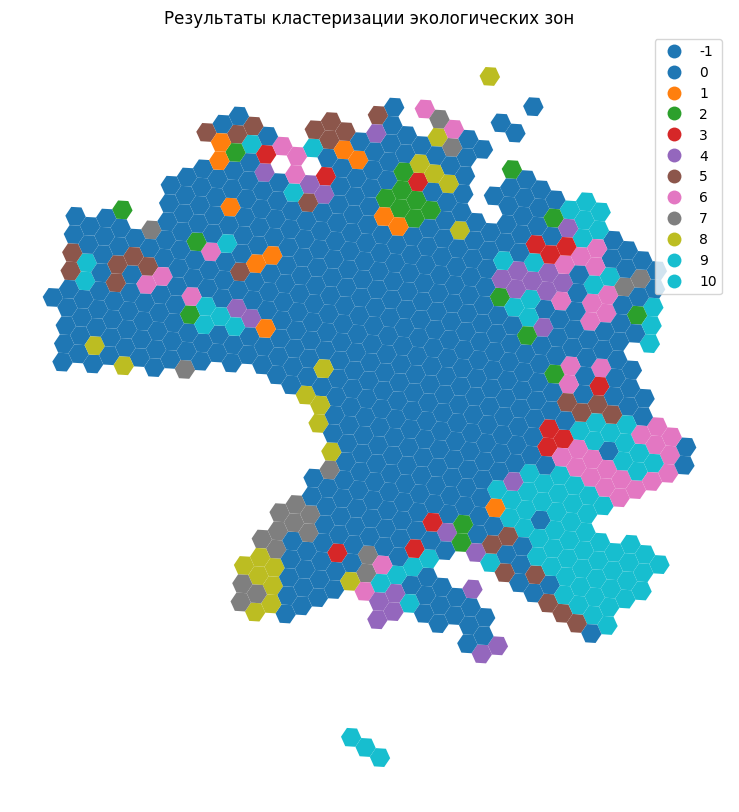

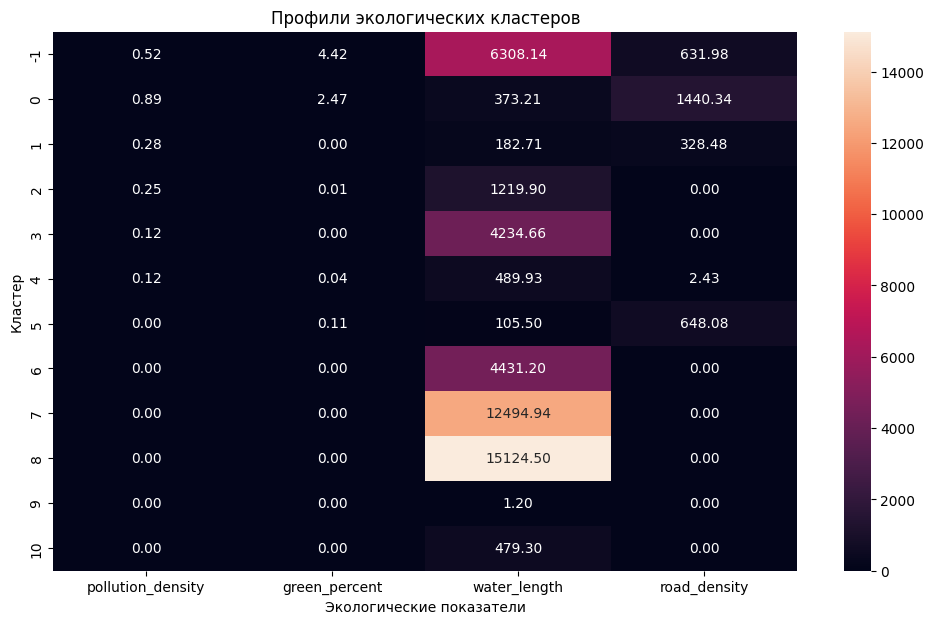

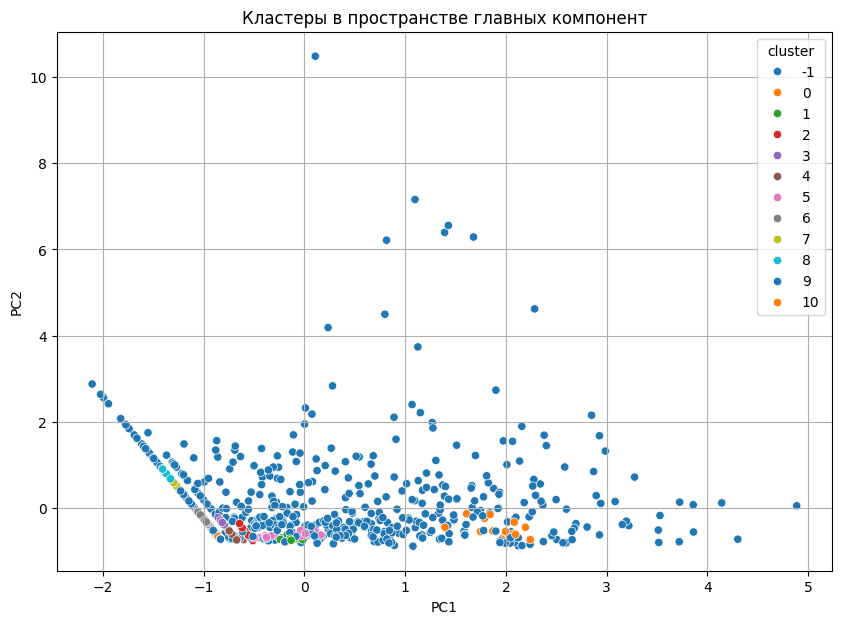

,pollution_density,green_percent,water_length,road_density
cluster,,,,
-1,0.52,4.42,6308.14,631.98
0,0.89,2.47,373.21,1440.34
1,0.28,0.00,182.71,328.48
2,0.25,0.01,1219.90,0.00
3,0.12,0.00,4234.66,0.00
4,0.12,0.04,489.93,2.43
5,0.00,0.11,105.50,648.08
6,0.00,0.00,4431.20,0.00
7,0.00,0.00,12494.94,0.00


Характеристики кластеров:

Кластер -1
Загрязнение: 0.52
Зеленые территории: 4.42
Водные объекты: 6308.14
Плотность дорог: 631.98

Кластер 0
Загрязнение: 0.89
Зеленые территории: 2.47
Водные объекты: 373.21
Плотность дорог: 1440.34

Кластер 1
Загрязнение: 0.28
Зеленые территории: 0.0
Водные объекты: 182.71
Плотность дорог: 328.48

Кластер 2
Загрязнение: 0.25
Зеленые территории: 0.01
Водные объекты: 1219.9
Плотность дорог: 0.0

Кластер 3
Загрязнение: 0.12
Зеленые территории: 0.0
Водные объекты: 4234.66
Плотность дорог: 0.0

Кластер 4
Загрязнение: 0.12
Зеленые территории: 0.04
Водные объекты: 489.93
Плотность дорог: 2.43

Кластер 5
Загрязнение: 0.0
Зеленые территории: 0.11
Водные объекты: 105.5
Плотность дорог: 648.08

Кластер 6
Загрязнение: 0.0
Зеленые территории: 0.0
Водные объекты: 4431.2
Плотность дорог: 0.0

Кластер 7
Загрязнение: 0.0
Зеленые территории: 0.0
Водные объекты: 12494.94
Плотность дорог: 0.0

Кластер 8
Загрязнение: 0.0
Зеленые территории: 0.0
Водные объекты: 15124.5
Плотн

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

grid.plot(
    column="cluster",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title(
    "Результаты кластеризации экологических зон"
)

ax.set_axis_off()
plt.show()

cluster_profile = grid.groupby("cluster")[
    feature_columns
].mean()

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f"
)

plt.title("Профили экологических кластеров")
plt.xlabel("Экологические показатели")
plt.ylabel("Кластер")
plt.show()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = grid["cluster"].values

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10"
)

plt.title("Кластеры в пространстве главных компонент")
plt.grid(True)
plt.show()

display(
    cluster_profile.round(2)
)

print("Характеристики кластеров:")

for cluster in sorted(grid["cluster"].unique()):

    profile = cluster_profile.loc[cluster]

    print()
    print("Кластер", cluster)

    print(
        "Загрязнение:",
        round(profile["pollution_density"], 2)
    )

    print(
        "Зеленые территории:",
        round(profile["green_percent"], 2)
    )

    print(
        "Водные объекты:",
        round(profile["water_length"], 2)
    )

    print(
        "Плотность дорог:",
        round(profile["road_density"], 2)
    )

### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей
- Оцените качество моделей с использованием кросс-валидации
- Выберите оптимальную модель и сохраните её для дальнейшего использования

In [ ]:
data = grid[feature_columns + ["cluster"]].copy()

data = data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

X = data[feature_columns]
y = data["cluster"]

print("Распределение классов:")
print(y.value_counts())

if y.nunique() >= 2:

    class_counts = y.value_counts()

    if class_counts.min() >= 2:

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.25,
            random_state=42,
            stratify=y
        )

        models = {
            "LogisticRegression": make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=2000
                )
            ),

            "DecisionTree": DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            ),

            "RandomForest": RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ),

            "GradientBoosting": GradientBoostingClassifier(
                random_state=42
            ),

            "SVM": make_pipeline(
                StandardScaler(),
                SVC()
            ),

            "KNN": make_pipeline(
                StandardScaler(),
                KNeighborsClassifier(
                    n_neighbors=5
                )
            )
        }

        results = []

        for name, model in models.items():

            model.fit(
                X_train,
                y_train
            )

            prediction = model.predict(X_test)

            accuracy = accuracy_score(
                y_test,
                prediction
            )

            precision = precision_score(
                y_test,
                prediction,
                average="weighted",
                zero_division=0
            )

            recall = recall_score(
                y_test,
                prediction,
                average="weighted",
                zero_division=0
            )

            f1 = f1_score(
                y_test,
                prediction,
                average="weighted",
                zero_division=0
            )

            cv_scores = cross_val_score(
                model,
                X,
                y,
                cv=5,
                scoring="accuracy"
            )

            results.append([
                name,
                accuracy,
                precision,
                recall,
                f1,
                cv_scores.mean()
            ])

        results_df = pd.DataFrame(
            results,
            columns=[
                "model",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "cv_accuracy"
            ]
        )

        display(
            results_df.sort_values(
                "cv_accuracy",
                ascending=False
            )
        )

        best_model_name = results_df.sort_values(
            "cv_accuracy",
            ascending=False
        ).iloc[0]["model"]

        best_model = models[best_model_name]

        best_model.fit(
            X,
            y
        )

        import joblib

        joblib.dump(
            best_model,
            "best_ecological_model.pkl"
        )

        print(
            "Сохранена модель:",
            best_model_name
        )

    else:

        print(
            "Недостаточно объектов в одном из классов "
            "для стратифицированного обучения."
        )

else:

    print(
        "Классификация невозможна: "
        "обнаружен только один класс."
    )

Распределение классов:
cluster
-1     479
 9      70
 6      40
 5      27
 10     25
 4      25
 8      21
 7      20
 2      19
 3      13
 0      13
 1      11
Name: count, dtype: int64


,model,accuracy,precision,recall,f1,cv_accuracy
2,RandomForest,0.937173,0.929798,0.937173,0.929687,0.950181
5,KNN,0.942408,0.956465,0.942408,0.945880,0.946276
3,GradientBoosting,0.952880,0.924647,0.952880,0.937264,0.943636
1,DecisionTree,0.921466,0.922188,0.921466,0.920043,0.927872
0,LogisticRegression,0.717277,0.614546,0.717277,0.635603,0.715600
4,SVM,0.680628,0.504552,0.680628,0.576089,0.689413


Сохранена модель: RandomForest


## **Отчёт**



«Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации»

Территория исследования: Казань, Россия

1. Описание территории и источников данных

Цель работы — провести пространственный анализ экологического состояния городской территории с использованием методов кластеризации и классификации.

В качестве территории исследования была выбрана Казань. Пространственные данные получены из OpenStreetMap. В исследовании рассматривались четыре основные группы объектов:

источники загрязнения — 545 объектов;
зелёные территории — 2168 объектов;
водные объекты — 428 объектов;
дорожная инфраструктура — 2317 объектов.

Полученные данные использовались для расчёта экологических характеристик отдельных участков территории.

2. Методика расчёта экологических показателей

Для пространственного анализа территория была разделена на гексагональную сетку H3 с разрешением 8. Каждая ячейка рассматривалась как отдельная область исследования.

Для каждой ячейки рассчитывались:

количество и плотность источников загрязнения;
площадь и доля зелёных территорий;
протяжённость водных объектов;
плотность автомобильных дорог.

При расчётах использовались буферные зоны 1600 м для источников загрязнения, водных объектов и дорог и 800 м для зелёных территорий.

После расчёта показатели были нормализованы. На их основе сформирован интегральный экологический индекс:

Экологический индекс = − загрязнение + зелёные территории + водные объекты − плотность дорог.

Таким образом, загрязнение и дорожная нагрузка ухудшают значение индекса, а наличие зелёных и водных объектов повышает его.

3. Сравнительный анализ кластеризации

Для выделения территорий со схожими экологическими характеристиками были применены K-Means, Agglomerative, Spectral, DBSCAN и HDBSCAN.

Для сравнения использовались метрики Silhouette Score, Davies–Bouldin Index и Calinski–Harabasz Index.

Алгоритм	Кластеров	Silhouette
HDBSCAN	11	0,646
K-Means	6	0,468
Agglomerative	6	0,431
Spectral	6	0,023
DBSCAN	1	—

Наибольшее значение Silhouette Score получил HDBSCAN — 0,646. В результате работы он выделил 11 кластеров и 479 шумовых объектов.

4. Карты и визуализация результатов

Для анализа результатов была построена карта распределения экологических кластеров по территории Казани.

Кроме карты, использовались:

тепловая карта характеристик кластеров;
визуализация данных с помощью PCA;
графики и таблицы со средними значениями экологических показателей.

PCA позволил представить многомерные данные на двумерной плоскости и наглядно показать различия между выделенными кластерами.

Полученные визуализации позволяют оценить пространственное расположение экологических зон и сравнить их характеристики.

5. Характеристика экологических зон

Выделенные кластеры отличаются уровнем загрязнения, количеством зелёных территорий, наличием водных объектов и дорожной нагрузкой.

Наиболее выраженная комбинация загрязнения и транспортной нагрузки наблюдается в кластере 0. Для подобных территорий целесообразно рассматривать мероприятия по снижению транспортного и промышленного воздействия, а также увеличению площади зелёных зон.

Некоторые кластеры характеризуются значительной протяжённостью водных объектов при низкой дорожной нагрузке. Для таких территорий важно сохранять существующее состояние водных и природных объектов.

Таким образом, кластеризация позволяет разделить городскую территорию на зоны с различными экологическими характеристиками и определить направления дальнейшего анализа.

6. Анализ моделей классификации

Для классификации полученных экологических зон были обучены шесть моделей:

Logistic Regression;
Decision Tree;
Random Forest;
Gradient Boosting;
SVM;
KNN.

Модели оценивались по Accuracy, Precision, Recall, F1 и результатам пятифолдовой кросс-валидации.

Наибольшее значение CV Accuracy — 0,9502 получил Random Forest. Поэтому именно эта модель была сохранена для дальнейшего использования в файле best_ecological_model.pkl.

При проверке на тестовой выборке максимальная Accuracy составила 0,9529 у Gradient Boosting.

7. Вывод

В ходе работы был проведён геоанализ экологических факторов городской среды Казани на основе данных OpenStreetMap и гексагональной сетки H3.

Были рассчитаны основные экологические показатели, сформирован интегральный экологический индекс и выполнено сравнение пяти алгоритмов кластеризации. HDBSCAN показал Silhouette Score 0,646 и выделил 11 кластеров.

Также были исследованы модели классификации экологических зон. Наибольшую среднюю точность при пятифолдовой кросс-валидации показал Random Forest — 0,9502.

Полученные результаты могут использоваться для экологического мониторинга, анализа городской среды, выявления территорий с повышенной нагрузкой и планирования природоохранных мероприятий.